# Suite2p Grid Search

Demonstrates parameter grid-search on `threshold_scaling` and `max_overlap` in suite2p.

These are [roi detection parameters](https://suite2p.readthedocs.io/en/latest/settings.html#roi-detection-settings). 

- `threshold_scaling` (default: 1.0): controls how much you want your neurons to "stand out" from the noise to count as a cell, lower will detect more cells.
- `max_overlap` (default: 0.75): set to 1 will allow all overlapping ROI's, 0.5 means if half of the cell is overlapping the roi will be discarded.

In [2]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import suite2p
import mbo_utilities as mbo
import lbm_suite2p_python as lsp

## Data path setup

In [7]:
data_dir = Path(r"D:\W2_DATA\kbarber\2025_03_01\mk301")
assembled_path = data_dir.joinpath("assembled")  # where the assembled tiffs are saved
save_path = data_dir.joinpath("results_gridsearch")
print(f"Saving raw tiffs to:        {assembled_path}")
print(f"Saving suite2p results to:  {save_path}")

Saving raw tiffs to:        D:\W2_DATA\kbarber\2025_03_01\mk301\assembled
Saving suite2p results to:  D:\W2_DATA\kbarber\2025_03_01\mk301\results_gridsearch


In [8]:
input_files = mbo.get_files(assembled_path, str_contains='tif', max_depth=3)
input_files = [Path(x) for x in input_files]
input_files[:3]

[WindowsPath('D:/W2_DATA/kbarber/2025_03_01/mk301/assembled/plane_01_mk301.tiff'),
 WindowsPath('D:/W2_DATA/kbarber/2025_03_01/mk301/assembled/plane_02_mk301.tiff'),
 WindowsPath('D:/W2_DATA/kbarber/2025_03_01/mk301/assembled/plane_03_mk301.tiff')]

## Define parameter values to change 

In [ ]:
from itertools import product

scaling_variants = [1.2, 1, .8]
overlap_variants = [.9, .75, .6]
parameter_grid = list(product(scaling_variants, overlap_variants))

base_dir = save_path.parent / 'grid_search'
base_dir.mkdir(exist_ok=True)

mdata = mbo.get_metadata(input_files[9])
ops = mbo.params_from_metadata(mdata, suite2p.default_ops())

Ops provided. Setting pipeline to suite2p


In [ ]:
from copy import deepcopy

for scaling, overlap in parameter_grid:
    dir_name = f"thrscale_{scaling}_overlap_{overlap}".replace(".", "_")
    path = base_dir.joinpath(dir_name)
    path.mkdir(exist_ok=True)
    new_ops = deepcopy(ops)
    new_ops['threshold_scaling'] = scaling
    new_ops['max_overlap'] = overlap
    ops['save_path0'] = str(path)
    opsEnd=suite2p.run_s2p(ops=new_ops,db={'data_path': [str(input_files[9].parent)], 'save_path': [path]})

In [14]:
ops_files = mbo.get_files(base_dir, 'ops', 4)
ops_files

['D:\\W2_DATA\\kbarber\\2025-02-27\\mk301\\grid_search\\thrscale_0_8_overlap_0_75\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-27\\mk301\\grid_search\\thrscale_0_8_overlap_0_9\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-27\\mk301\\grid_search\\thrscale_1_2_overlap_0_6\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-27\\mk301\\grid_search\\thrscale_1_2_overlap_0_75\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-27\\mk301\\grid_search\\thrscale_1_2_overlap_0_9\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-27\\mk301\\grid_search\\thrscale_1_overlap_0_6\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-27\\mk301\\grid_search\\thrscale_1_overlap_0_75\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-27\\mk301\\grid_search\\thrscale_1_overlap_0_9\\suite2p\\plane0\\ops.npy']

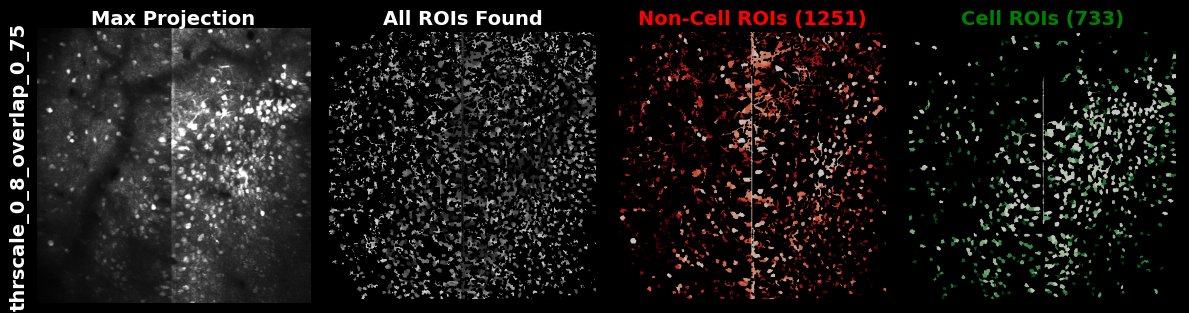

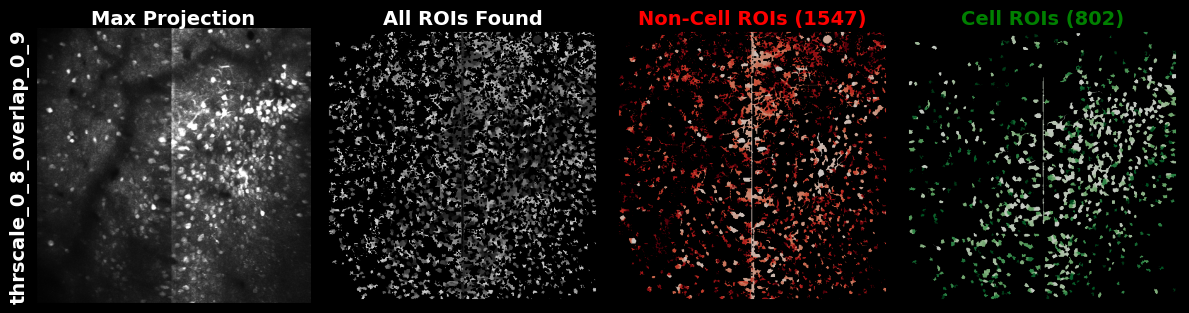

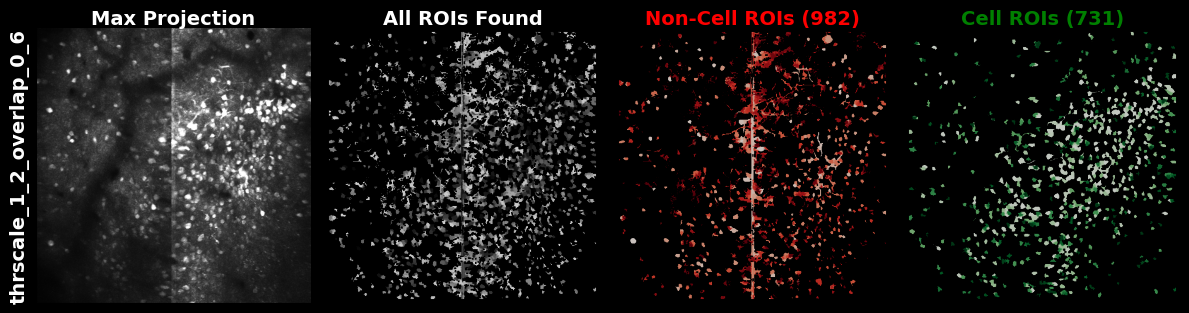

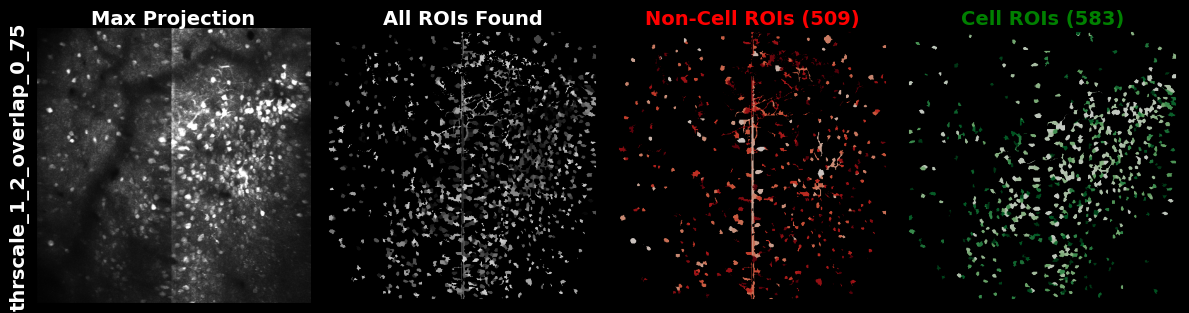

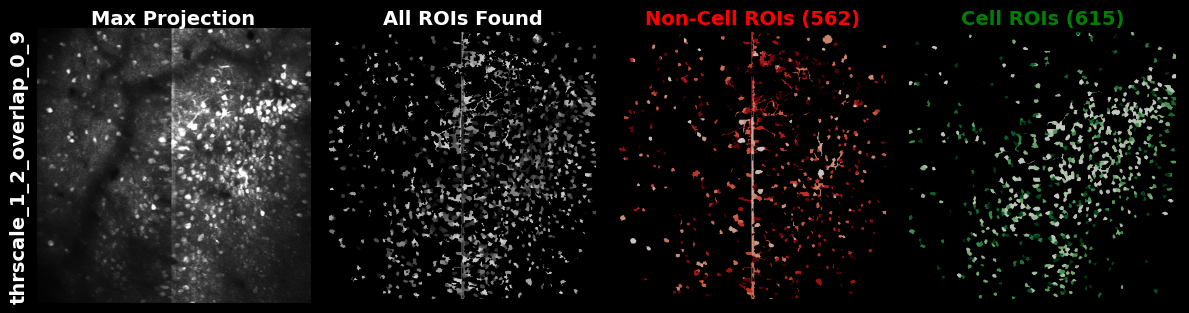

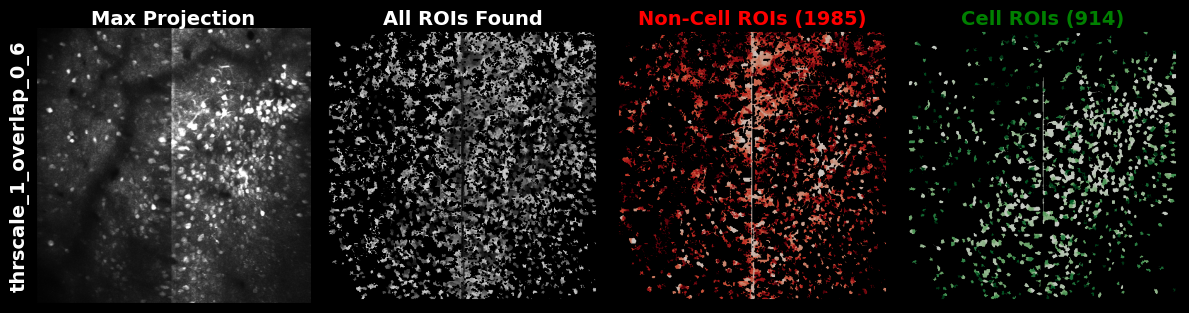

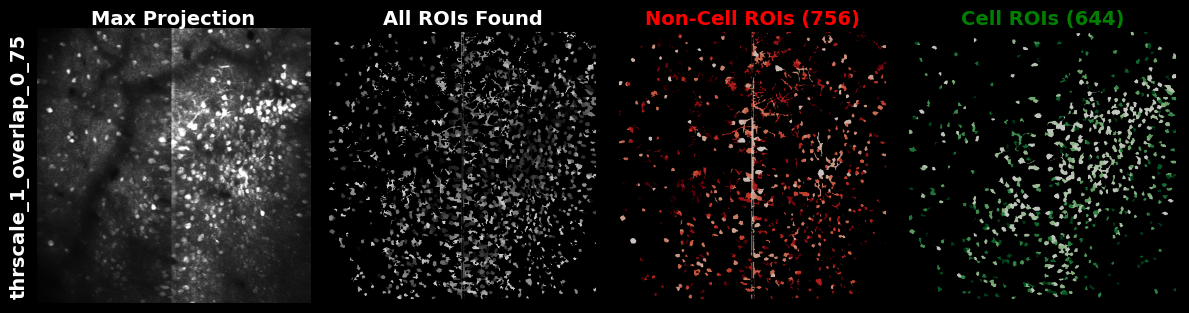

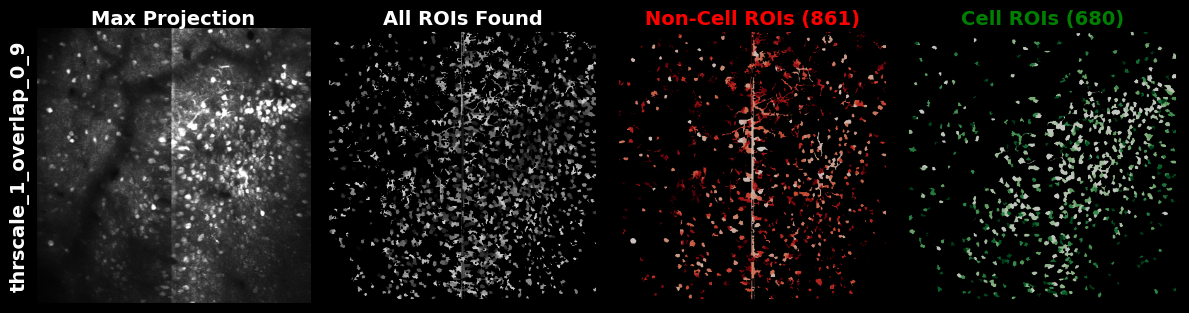

In [44]:
for op in ops_files:
    ops_dict = lsp.load_ops(op)
    root_dir = Path(ops_dict['save_path'])
    plane_name = Path(ops_dict["tiff_list"][0]).stem
    prepend_str = root_dir.parent.parent.name
    save_name = base_dir / 'grid_figs'
    save_name.mkdir(exist_ok=True)
    full_savename = save_name / f"{plane_name}_{prepend_str}"
    # lsp.plot_segmentation(ops_dict, f"{full_savename}_segmentation.png", overlay=True, fig_label = prepend_str)
    lsp.plot_segmentation(ops_dict, f"{full_savename}_segmentation_overlay.png", overlay=False, fig_label=prepend_str)